**1. Imports**

In [1]:
import os
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/prangyakumarinayak/Desktop/Career-2026/09_Projects/telco-churn-analysis/notebooks


In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
#2. Data Loading
import pandas as pd

#3. EDA
import matplotlib.pyplot as plt
import seaborn as sns

#4. Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#5. Training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from src.models.evaluate import evaluate_model

#7. Dashboard
import plotly.express as px

**2. Data Loading**

In [4]:
from src.data.loader import load_telco_churn_data

df = load_telco_churn_data()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**3. EDA**

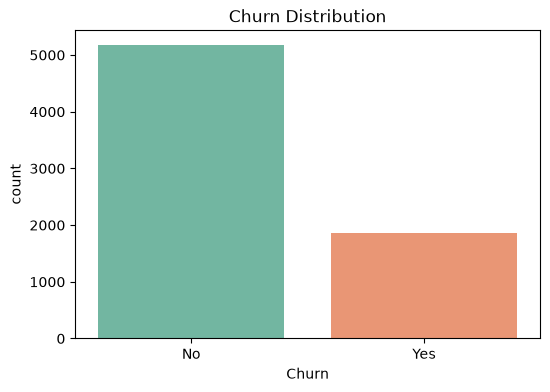

In [5]:
# 1. Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", hue="Churn", data=df, palette="Set2" , legend=False)
plt.title("Churn Distribution")
plt.show()

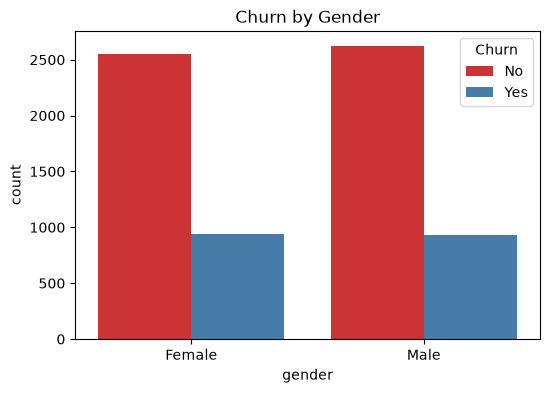

In [6]:
# 2. Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df, palette="Set1")
plt.title("Churn by Gender")
plt.show()

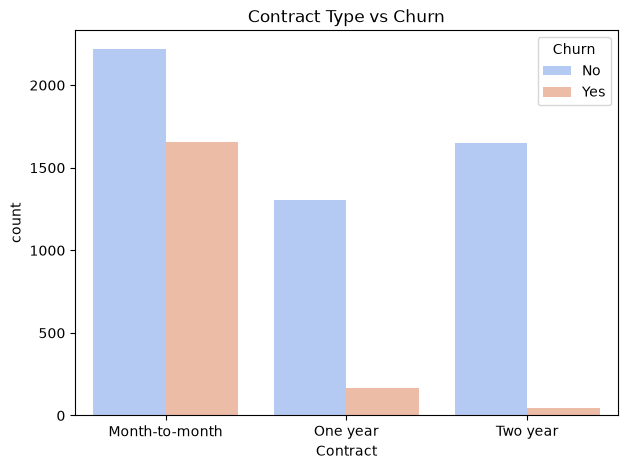

In [7]:
# 3. Contract Type vs Churn
plt.figure(figsize=(7,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="coolwarm")
plt.title("Contract Type vs Churn")
plt.show()

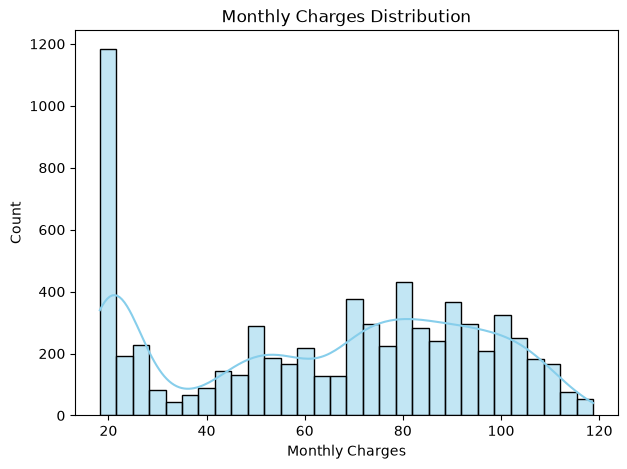

In [8]:
# 4. Monthly Charges Distribution
plt.figure(figsize=(7,5))
sns.histplot(df["MonthlyCharges"], kde=True, bins=30, color="skyblue")
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

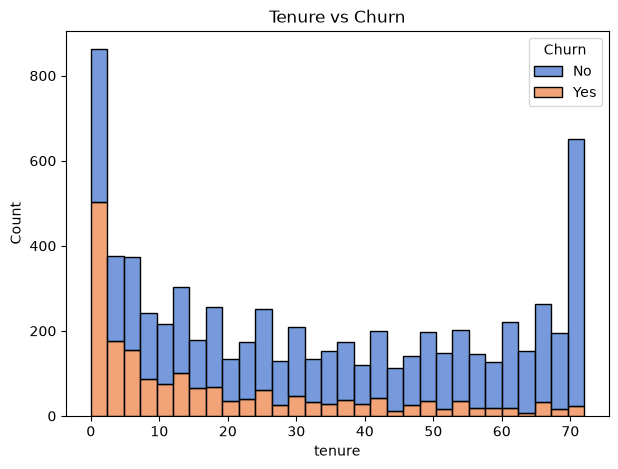

In [9]:
# 5. Tenure vs Churn
plt.figure(figsize=(7,5))
sns.histplot(x="tenure", hue="Churn", data=df, bins=30, multiple="stack", palette="muted")
plt.title("Tenure vs Churn")
plt.show()

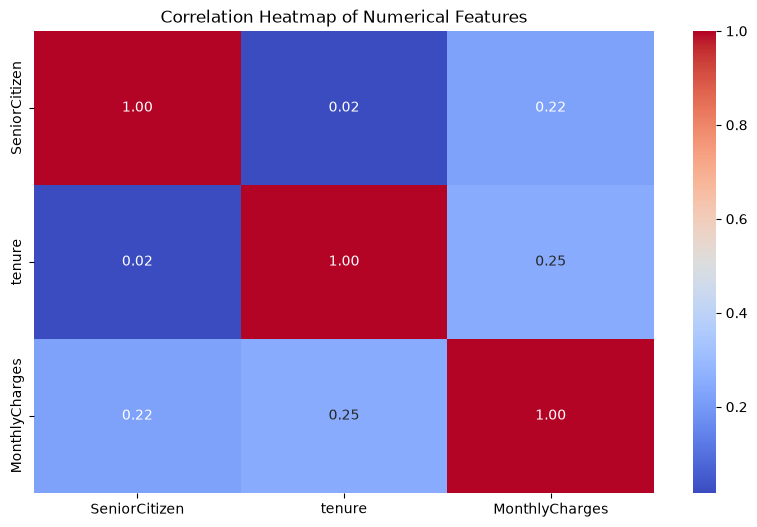

In [10]:
# 6. Correlation Heatmap (for numeric features only)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**4. Preprocessing**

In [11]:
# Drop customerID
df = df.drop("customerID", axis=1)

In [12]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [13]:
# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [14]:
# Encode categorical columns
encoder = LabelEncoder()

for column in df.columns:
    if not pd.api.types.is_numeric_dtype(df[column]):
        df[column] = encoder.fit_transform(
            df[column].astype(str)
        )

In [15]:
# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Standardize feature values before training
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**5. Training**

In [18]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_accuracy, log_report, log_matrix = evaluate_model(y_test, y_pred_log)

print("🔹 Logistic Regression Results")
print("Accuracy:", log_accuracy)
print(log_report)

🔹 Logistic Regression Results
Accuracy: 0.815471965933286
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [19]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy, rf_report, rf_matrix = evaluate_model(y_test, y_pred_rf)

print("\n🔹 Random Forest Results")
print("Accuracy:", rf_accuracy)
print(rf_report)


🔹 Random Forest Results
Accuracy: 0.7963094393186657
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



**6. Evaluation**

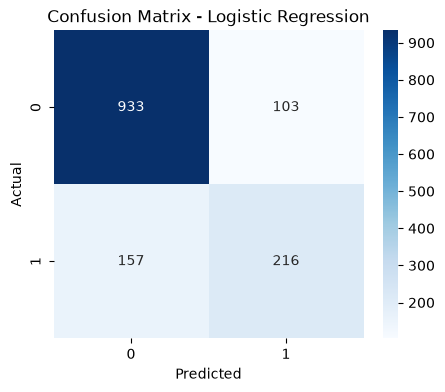

In [20]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(5,4))
sns.heatmap(log_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

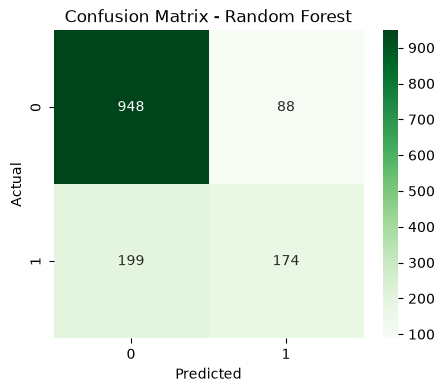

In [21]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(5,4))
sns.heatmap(rf_matrix, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

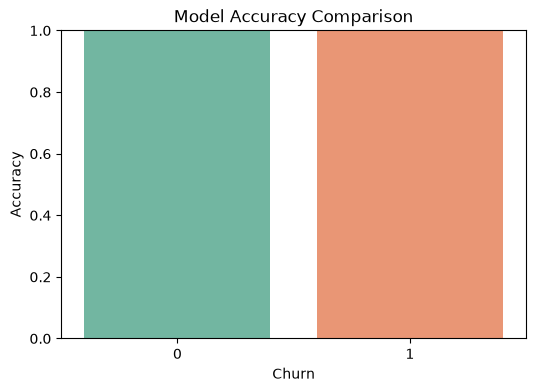

In [22]:
# Compare Model Accuracy
accuracy_scores = {
    "Logistic Regression": log_accuracy,
    "Random Forest": rf_accuracy,
}

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", hue="Churn", data=df, palette="Set2", legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

**7. Dashboard**

In [23]:
# Churn distribution
fig1 = px.histogram(df, x="Churn", color="Churn", title="Churn Distribution")
fig1.show()

In [24]:
# Contract vs Churn
fig2 = px.histogram(df, x="Contract", color="Churn", barmode="group", title="Contract Type vs Churn")
fig2.show()

In [25]:
# Monthly Charges vs Churn
fig3 = px.box(df, x="Churn", y="MonthlyCharges", color="Churn", title="Monthly Charges vs Churn")
fig3.show()